# Horizontal Cross Sections of Lag Plots (Spatial Extent Across Latitude)

In [2]:
import usefulfunc as uf
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os

In [3]:
WORK = os.environ["WORK"]   

In [4]:
zmTdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmTdanoms1979_2023.nc')
zmUdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmUdanoms1979_2023.nc')
zmWdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmWdanoms1979_2023.nc')
zmzdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmzdanoms1979_2023.nc')

In [5]:
stzmTdanomts = zmTdanoms79_23.T.stack(alltime = ('year', 'time'))
stzmUdanomts = zmUdanoms79_23.U.stack(alltime = ('year', 'time'))
stzmWdanomts = zmWdanoms79_23.W.stack(alltime = ('year', 'time'))
stzmzdanomts = zmzdanoms79_23.Z.stack(alltime = ('year', 'time'))

In [6]:
stzmTdanomts

<xarray.DataArray 'T' (level: 37, latitude: 721, alltime: 16425)> Size: 4GB
dask.array<reshape, shape=(37, 721, 16425), dtype=float64, chunksize=(37, 721, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * alltime   (alltime) object 131kB MultiIndex
  * year      (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time      (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [8]:
z850 = stzmzdanomts.sel(level=850, latitude=0)
z850highp, z850lowp = uf.butter1yhighp(z850, 4)

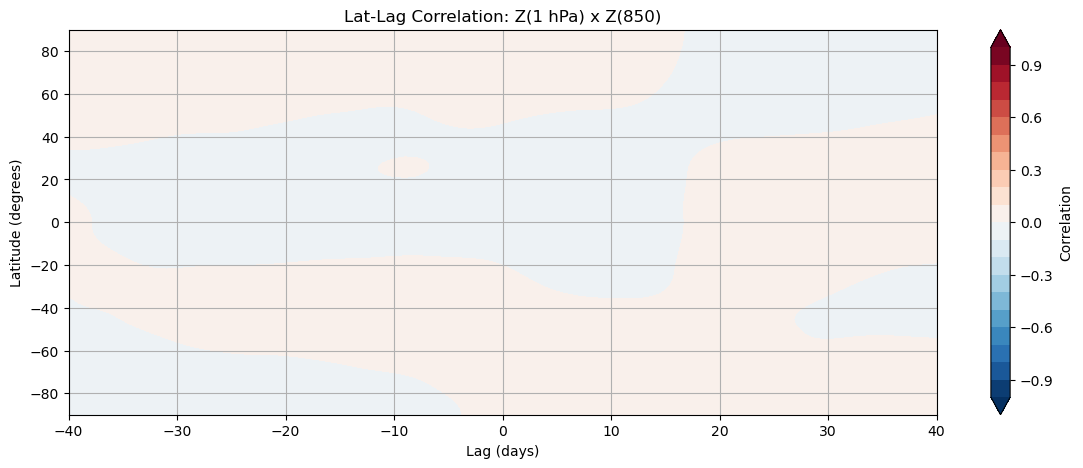

In [5]:

edge_trim = 183
all_corrs = []
# Loop through all levels

for level in stzmzdanomts.level.values:
    zp = stzmzdanomts.sel(level=level)  # (latitude, alltime)
    zphighp, zplowp = uf.butter1yhighp(zp, order=4)  # Filter just this level
    
    lhighpzsh = zphighp.isel(alltime=slice(edge_trim, -edge_trim))
    zlags, zlatitudes, zcorrelations = uf.lat_lag_corr(z850highp, lhighpzsh)
    all_corrs.append(zcorrelations)

# Set up the figure for animation
fig, ax = plt.subplots(figsize=(14, 5))

def animate(i):
    ax.clear()
    cs = ax.contourf(
        zlags, zlatitudes, all_corrs[i],
        levels=np.linspace(-1, 1, 21), cmap="RdBu_r", extend="both"
    )
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_title(f'Lat-Lag Correlation: Z({stzmzdanomts.level.values[i]:.0f} hPa) x Z(850)')
    ax.grid(True)
    return cs,

anim = FuncAnimation(fig, animate, frames=len(stzmzdanomts.level.values), interval=200, blit=False)

# Add colorbar
plt.colorbar(ax.contourf(zlags, zlatitudes, all_corrs[0], levels=np.linspace(-1, 1, 21), cmap="RdBu_r", extend="both"), 
ax=ax, label="Correlation")

# Display in notebook
HTML(anim.to_jshtml())

#anim.save('zpz850lat.gif', writer='pillow', fps=5)
# anim.save('lat_lag_animation.mp4', writer='ffmpeg', fps=5)

TypeError: Input z must be 2D, not 1D

Error in callback <function _draw_all_if_interactive at 0x1530c0190cc0> (for post_execute), with arguments args (),kwargs {}:


TypeError: Input z must be 2D, not 1D

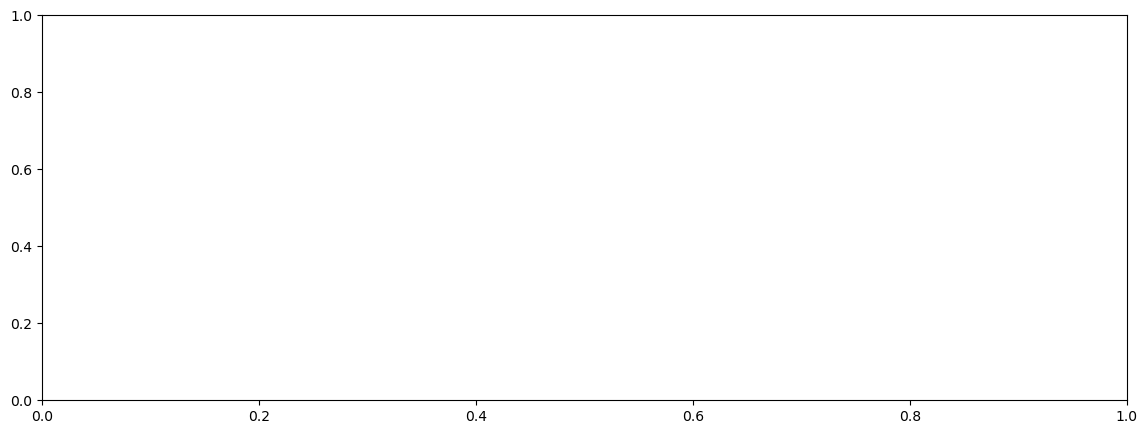

In [11]:
edge_trim = 183
all_corrs = []
# Loop through all levels

for level in stzmUdanomts.level.values:
    zp = stzmUdanomts.sel(level=level)  # (latitude, alltime)
    zphighp, zplowp = uf.butter1yhighp(zp, order=4)  # Filter just this level
    
    lhighpzsh = zphighp.isel(alltime=slice(edge_trim, -edge_trim))
    zcorr = uf.lat_lag_corr(z850highp, lhighpzsh)
    all_corrs.append(zcorr.values)

# Set up the figure for animation
fig, ax = plt.subplots(figsize=(14, 5))

def animate(i):
    ax.clear()
    cs = ax.contourf(
        zcorr.lag, zcorr.latitude, zcorr.values[i],
        levels=np.linspace(-0.25, 0.25, 21), cmap="RdBu_r", extend="both"
    )
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_title(f'Lat-Lag Correlation: U({stzmUdanomts.level.values[i]:.0f} hPa) x Z(850)')
    return cs,

Uanim = FuncAnimation(fig, animate, frames=len(stzmUdanomts.level.values), interval=200, blit=False)

# Add colorbar
plt.colorbar(ax.contourf(zcorr.lag, zcorr.latitude, zcorr.values[0], levels=np.linspace(-0.25, 0.25, 21), cmap="RdBu_r", extend="both"), 
ax=ax, label="Correlation")

# Display in notebook
HTML(anim.to_jshtml())

# Or save
#Uanim.save('Upz850lat.gif', writer='pillow', fps=5)
# anim.save('lat_lag_animation.mp4', writer='ffmpeg', fps=5)

In [ ]:
edge_trim = 183
all_corrs = []

for level in stzmTdanomts.level.values:
    zp = stzmTdanomts.sel(level=level)  
    zphighp, zplowp = uf.butter1yhighp(zp, order=4)  
    
    lhighpzsh = zphighp.isel(alltime=slice(edge_trim, -edge_trim))
    tcorr= uf.lat_lag_corr(z850highp, lhighpzsh)
    all_corrs.append(tcorr.values)

fig, ax = plt.subplots(figsize=(14, 5))

def animate(i):
    ax.clear()
    cs = ax.contourf(
        zcorr.lag, zcorr.latitude, zcorr.values[i],
        levels=np.linspace(-0.35, 0.35, 21), cmap="RdBu_r", extend="both"
    )
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_title(f'Lat-Lag Correlation: T({stzmTdanomts.level.values[i]:.0f} hPa) x Z(850)')
    return cs,

Tanim = FuncAnimation(fig, animate, frames=len(stzmTdanomts.level.values), interval=200, blit=False)


plt.colorbar(ax.contourf(tcorr.lag, tcorr.latitude, tcorr.values[0], levels=np.linspace(-0.35, 0.35, 21), cmap="RdBu_r", extend="both"), 
ax=ax, label="Correlation")

HTML(anim.to_jshtml())

#Tanim.save('Tpz850lat.gif', writer='pillow', fps=5)
# anim.save('lat_lag_animation.mp4', writer='ffmpeg', fps=5)

In [ ]:
edge_trim = 183
all_corrs = []


for level in stzmWdanomts.level.values:
    zp = stzmWdanomts.sel(level=level)  
    zphighp, zplowp = uf.butter1yhighp(zp, order=4)  
    
    lhighpzsh = zphighp.isel(alltime=slice(edge_trim, -edge_trim))
    wcorr = uf.lat_lag_corr(z850highp, lhighpzsh)
    all_corrs.append(wcorr.values)

fig, ax = plt.subplots(figsize=(14, 5))

def animate(i):
    ax.clear()
    cs = ax.contourf(
        wcorr.lag, wcorr.latitude, wcorr.values[i],
        levels=np.linspace(-0.15, 0.15, 21), cmap="RdBu_r", extend="both"
    )
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_title(f'Lat-Lag Correlation: W({stzmWdanomts.level.values[i]:.0f} hPa) x Z(850)')
    return cs,

Wanim = FuncAnimation(fig, animate, frames=len(stzmWdanomts.level.values), interval=200, blit=False)

plt.colorbar(ax.contourf(wcorr.lag, wcorr.latitude, wcorr.values[0], levels=np.linspace(-0.15, 0.15, 21), cmap="RdBu_r", extend="both"), 
ax=ax, label="Correlation")

HTML(Wanim.to_jshtml())

# Or save
#Wanim.save('Wpz850lat.gif', writer='pillow', fps=5)
# anim.save('lat_lag_animation.mp4', writer='ffmpeg', fps=5)